### Maestría en Ciencia de Datos
### PIA Datos Masivos 2025
Gema Guerra Valdez - 1819110

In [1]:
import os
import sys

# Force Spark to use the exact Python executable running this notebook
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# Point to your Spark installation
os.environ['SPARK_HOME'] = r'C:\spark'

# Windows-specific: Spark needs Hadoop binaries (winutils.exe)
# Ensure you have winutils.exe in C:\hadoop\bin
os.environ['HADOOP_HOME'] = r'C:\hadoop' 
os.environ['PATH'] += os.pathsep + r'C:\hadoop\bin'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PIA_Gema") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.nio=ALL-UNNAMED " +
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.nio=ALL-UNNAMED " +
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED") \
    .getOrCreate()

sc = spark.sparkContext


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hrokrin/the-largest-diamond-dataset-currely-on-kaggle")

print("Path to dataset files:", path)

c:\Users\gema2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\gema2\.cache\kagglehub\datasets\hrokrin\the-largest-diamond-dataset-currely-on-kaggle\versions\1


In [4]:
path = r"C:\Users\gema2\.cache\kagglehub\datasets\hrokrin\the-largest-diamond-dataset-currely-on-kaggle\versions\1\diamonds.csv"

# Leer el dataset
df = spark.read.csv(path, header=True, inferSchema=True)

# Ver esquema de columnas
df.printSchema()



root
 |-- _c0: integer (nullable = true)
 |-- cut: string (nullable = true)
 |-- color: string (nullable = true)
 |-- clarity: string (nullable = true)
 |-- carat_weight: double (nullable = true)
 |-- cut_quality: string (nullable = true)
 |-- lab: string (nullable = true)
 |-- symmetry: string (nullable = true)
 |-- polish: string (nullable = true)
 |-- eye_clean: string (nullable = true)
 |-- culet_size: string (nullable = true)
 |-- culet_condition: string (nullable = true)
 |-- depth_percent: double (nullable = true)
 |-- table_percent: double (nullable = true)
 |-- meas_length: double (nullable = true)
 |-- meas_width: double (nullable = true)
 |-- meas_depth: double (nullable = true)
 |-- girdle_min: string (nullable = true)
 |-- girdle_max: string (nullable = true)
 |-- fluor_color: string (nullable = true)
 |-- fluor_intensity: string (nullable = true)
 |-- fancy_color_dominant_color: string (nullable = true)
 |-- fancy_color_secondary_color: string (nullable = true)
 |-- fancy

In [5]:
df.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'eye_clean',
 'culet_size',
 'culet_condition',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 'total_sales_price']

In [6]:
# Mostrar primeras filas
df.show(10)

+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-------------+-----------+----------+----------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------+-----------------+
|_c0|  cut|color|clarity|carat_weight|cut_quality|lab| symmetry|   polish|eye_clean|culet_size|culet_condition|depth_percent|table_percent|meas_length|meas_width|meas_depth|girdle_min|girdle_max|fluor_color|fluor_intensity|fancy_color_dominant_color|fancy_color_secondary_color|fancy_color_overtone|fancy_color_intensity|total_sales_price|
+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-------------+-----------+----------+----------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------

In [7]:
df.count()

219703

### Limpieza de Datos

In [8]:
from pyspark.sql.functions import col, when, count

# Separar columnas por tipo
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float")]
string_cols = [c for c, t in df.dtypes if t not in ("int", "double", "float")]

# Contar valores faltantes en columnas numéricas (None y NaN)
missing_numeric = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in numeric_cols
])

# Contar valores faltantes en columnas string (None y "Unknown")
missing_string = df.select([
    count(when(col(c).isNull()  | (col(c) == "unknown") | (col(c) == "None") , c)).alias(c)
    for c in string_cols
])

print("Valores faltantes en columnas numéricas:")
missing_numeric.show()



Valores faltantes en columnas numéricas:
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+
|_c0|carat_weight|depth_percent|table_percent|meas_length|meas_width|meas_depth|total_sales_price|
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+
|  0|           0|            0|            0|          0|         0|         0|                0|
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+



In [9]:
df_limpio= df.drop(
 'eye_clean',
 'culet_size',
 'culet_condition',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 )

In [10]:
df_limpio.dropna()

df_limpio = df.filter((col("color") != "unknown") & (col("cut_quality") != "unknown"))

df_limpio.count()

158991

In [11]:
# Contar valores faltantes en columnas string (None y "Unknown")
missing_string = df_limpio.select([
    count(when(col(c).isNull()  | (col(c) == "unknown") | (col(c) == "None") , c)).alias(c)
    for c in string_cols
])

print("Valores faltantes en columnas string:")
missing_string.show()

Valores faltantes en columnas string:
+---+-----+-------+-----------+---+--------+------+---------+----------+---------------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------+
|cut|color|clarity|cut_quality|lab|symmetry|polish|eye_clean|culet_size|culet_condition|girdle_min|girdle_max|fluor_color|fluor_intensity|fancy_color_dominant_color|fancy_color_secondary_color|fancy_color_overtone|fancy_color_intensity|
+---+-----+-------+-----------+---+--------+------+---------+----------+---------------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------+
|  0|    0|      0|          0|  0|       0|     0|   106448|     60240|         147998|     58463|     59117|     148543|         104794|                    158990|                     158991|              158987|               158991|
+---+-----+---

### Análisis Exploratorio

In [12]:
df_limpio.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'eye_clean',
 'culet_size',
 'culet_condition',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 'total_sales_price']

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

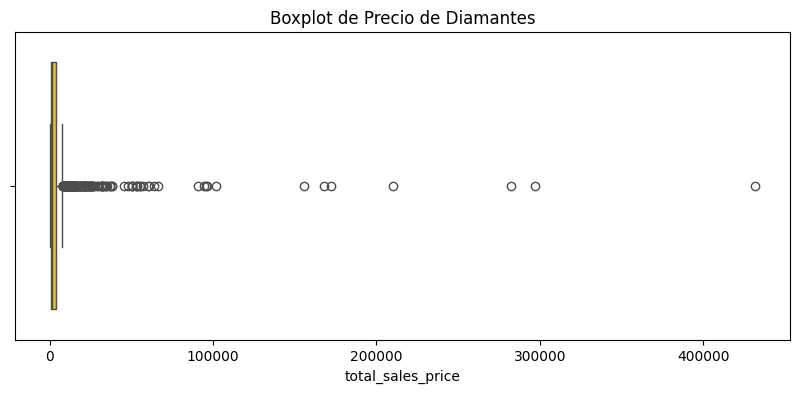

In [14]:
df_sample = df_limpio.select("total_sales_price").sample(False, 0.01).toPandas()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sample["total_sales_price"], color="gold")
plt.title("Boxplot de Precio de Diamantes")
plt.show()

In [15]:
df_limpio = df_limpio.filter(col("total_sales_price") < 50000)

In [16]:
from pyspark.sql.functions import log, exp

# Creamos la nueva etiqueta
df_log = df_limpio.withColumn("label_log", log(col("total_sales_price")))

# Dividimos de nuevo
train_log, test_log = df_log.randomSplit([0.7, 0.3], seed=42)

### Preparación de características

In [17]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.feature import StandardScaler

In [18]:
indexer = StringIndexer(
    inputCols=["cut", "color", "clarity", 'cut_quality','lab','symmetry','polish'],
    outputCols=["cut_index", "color_index", "clarity_index",'cut_quality_index','lab_index','symmetry_index','polish_index'],
    handleInvalid="keep"
)

df_indexed = indexer.fit(df_limpio).transform(df_limpio)
df_indexed.show(5)

+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-------------+-----------+----------+----------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------+-----------------+---------+-----------+-------------+-----------------+---------+--------------+------------+
|_c0|  cut|color|clarity|carat_weight|cut_quality|lab| symmetry|   polish|eye_clean|culet_size|culet_condition|depth_percent|table_percent|meas_length|meas_width|meas_depth|girdle_min|girdle_max|fluor_color|fluor_intensity|fancy_color_dominant_color|fancy_color_secondary_color|fancy_color_overtone|fancy_color_intensity|total_sales_price|cut_index|color_index|clarity_index|cut_quality_index|lab_index|symmetry_index|polish_index|
+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-----------

In [19]:
df_indexed.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'eye_clean',
 'culet_size',
 'culet_condition',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 'total_sales_price',
 'cut_index',
 'color_index',
 'clarity_index',
 'cut_quality_index',
 'lab_index',
 'symmetry_index',
 'polish_index']

In [20]:
from pyspark.ml.feature import OneHotEncoder

In [21]:
encoder = OneHotEncoder(
    inputCols=["cut_index", "color_index", "clarity_index",'cut_quality_index','lab_index','symmetry_index','polish_index'],
    outputCols=["cut_vec", "color_vec", "clarity_vec",'cut_quality_vec','lab_vec','symmetry_vec','polish_vec']
)

encoder_model = encoder.fit(df_indexed)
df_encoded = encoder_model.transform(df_indexed)

In [22]:
input_cols = [
 'carat_weight',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
'cut_vec', "color_vec", "clarity_vec",'cut_quality_vec','lab_vec','symmetry_vec','polish_vec']

In [23]:
assembler = VectorAssembler().setInputCols(input_cols).setOutputCol("vector_unificado")
df_vector = assembler.transform(df_encoded)

In [24]:
scaler = StandardScaler(inputCol="vector_unificado", outputCol="features_scaled", withStd=True, withMean=False)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

In [25]:
from pyspark.ml.feature import UnivariateFeatureSelector

In [26]:
selector = UnivariateFeatureSelector(featuresCol="features_scaled", labelCol= 'total_sales_price', outputCol="selectedFeatures")
selector.setFeatureType("continuous").setLabelType("continuous").setSelectionThreshold(8)

UnivariateFeatureSelector_2ece70cd1056

In [27]:
selector_model = selector.fit(df_scaled)
selected_df = selector_model.transform(df_scaled)

In [28]:
# Extraer los nombres de las variables elegidas
indices = selector_model.selectedFeatures
print(f"Variables seleccionadas: {[input_cols[i] for i in indices]}")

Variables seleccionadas: ['carat_weight', 'table_percent', 'meas_length', 'meas_width', 'meas_depth', 'cut_vec', 'color_vec', 'clarity_vec']


### Modelo de Predicción

In [29]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

In [31]:
lr = LinearRegression(featuresCol="selectedFeatures", labelCol="total_sales_price")

pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler, selector, lr])

train, test = df_limpio.randomSplit([0.7, 0.3], seed=42)

model = pipeline.fit(train)
predictions = model.transform(test)

evaluator = RegressionEvaluator(labelCol="total_sales_price", predictionCol="prediction", metricName="rmse")  
rmse = evaluator.evaluate(predictions)

print(f"Modelo entrenado con éxito.")
print(f"Error promedio (RMSE): ${round(rmse, 2)}")

evaluator_r2 = RegressionEvaluator(labelCol="total_sales_price", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)
print(f"Coeficiente de determinación (R2): {round(r2, 4)}")


Modelo entrenado con éxito.
Error promedio (RMSE): $2483.79
Coeficiente de determinación (R2): 0.8319


In [34]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.sql.functions import col, isnan

rf = RandomForestRegressor(
    featuresCol="selectedFeatures", 
    labelCol="total_sales_price",
    numTrees=50,
    maxDepth=10,
    seed=42
)

# 2. Re-build the Pipeline with the RF model
pipeline_rf = Pipeline(stages=[indexer, encoder, assembler, scaler, selector, rf])

# 3. Fit the model
model_rf = pipeline_rf.fit(train)

# 4. Make predictions
predictions_rf = model_rf.transform(test)

# 5. Clean and Evaluate
predictions_rf_clean = predictions_rf.filter(col("prediction").isNotNull() & (~isnan(col("prediction"))))
rmse_rf = evaluator.evaluate(predictions_rf_clean)

print(f"Random Forest RMSE: ${round(rmse_rf, 2)}")

evaluator_r2 = RegressionEvaluator(labelCol="total_sales_price", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)
print(f"Coeficiente de determinación (R2): {round(r2, 4)}")

Random Forest RMSE: $2440.65
Coeficiente de determinación (R2): 0.8319


In [35]:
# Cuánto afectan el resultado porcentualmente
rf_stage = model_rf.stages[-1] # Assuming RF is the last stage
print(rf_stage.featureImportances)

(8,[0,1,2,3,4,5,6,7],[0.301940884981936,0.003247177148374351,0.2445170859087629,0.2821743840378885,0.16641408186875506,0.0013296629883018268,0.00019082943649133475,0.00018589362948994082])


Ajuste de hiperparámetros de Random Forest

In [36]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 1. Create the Parameter Grid
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [50, 100])
             .addGrid(rf.maxDepth, [10, 15])
             .build())

# 2. Define the CrossValidator
# numFolds=3 means it will split your training data into 3 parts 
# to ensure the model isn't just "getting lucky" on one split.
cv = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

# 3. Run the search (This will take a few minutes!)
cvModel = cv.fit(train)

# 4. Use the "Best" model to predict
predictions_final = cvModel.transform(test)

In [37]:
bestModel = cvModel.bestModel
# The RF model is the last stage in your pipeline
final_rf_properties = bestModel.stages[-1]

print(f"Best numTrees: {final_rf_properties.getNumTrees}")
print(f"Best maxDepth: {final_rf_properties.getOrDefault('maxDepth')}")

Best numTrees: 50
Best maxDepth: 15


In [38]:
# 1. Usar el mejor modelo encontrado por el CrossValidator
modelo_produccion = cvModel.bestModel

# 2. Hacer predicciones finales
resultados = modelo_produccion.transform(test)

# 3. Mostrar las primeras 5 comparaciones: Real vs Predicho
resultados.select("total_sales_price", "prediction").show(5)

+-----------------+-----------------+
|total_sales_price|       prediction|
+-----------------+-----------------+
|              200|629.7045205950867|
|              200|636.0789145410406|
|              200|629.3501172067413|
|              200|636.0789145410406|
|              200|611.8151556799464|
+-----------------+-----------------+
only showing top 5 rows


In [39]:
# Actualizamos el Selector y el RF para usar la escala logarítmica
selector.setLabelCol("label_log")

rf_log = RandomForestRegressor(
    featuresCol="selectedFeatures", 
    labelCol="label_log",  # <--- Cambio clave
    numTrees=50,
    maxDepth=15,
    seed=42
)

# Re-armamos el pipeline
pipeline_log = Pipeline(stages=[indexer, encoder, assembler, scaler, selector, rf_log])

# Entrenamos
model_log = pipeline_log.fit(train_log)

In [40]:
# 1. Predecir
predictions_log = model_log.transform(test_log)

# 2. Convertir el logaritmo de vuelta a dólares reales
predictions_final = predictions_log.withColumn(
    "prediction_dollars", 
    exp(col("prediction"))
)

# 3. Ver el resultado para los diamantes baratos
predictions_final.select("total_sales_price", "prediction_dollars").show(5)

+-----------------+------------------+
|total_sales_price|prediction_dollars|
+-----------------+------------------+
|              200| 610.8085727244384|
|              200| 610.8085727244384|
|              200| 610.8085727244384|
|              200| 610.8085727244384|
|              200| 610.8085727244384|
+-----------------+------------------+
only showing top 5 rows


In [45]:
# 1. Aumentamos el umbral para incluir Color y Claridad (que son vitales en precios bajos)
selector.setSelectionThreshold(20) 

# 2. Le damos más "memoria" al Bosque para que cree reglas más finas
rf_log = RandomForestRegressor(
    featuresCol="selectedFeatures", 
    labelCol="label_log",
    numTrees=50,     
    maxDepth=12,      
    seed=42
)

# 3. Entrena de nuevo el pipeline_log
model_log_v2 = pipeline_log.fit(train_log)

In [46]:
# 1. Predecir (Escala Logarítmica)
predictions_log_2 = model_log_v2.transform(test_log)

# 2. Convertir a dólares (Para visualización humana)
predictions_final2 = predictions_log_2.withColumn(
    "prediction_dollars", 
    exp(col("prediction"))
)

# 3. Mostrar resultados
predictions_final2.select("total_sales_price", "prediction_dollars").show(5)

# --- EVALUACIÓN (CRÍTICO: Usar escala logarítmica para ambos) ---

# Evaluador para RMSE
evaluator_log = RegressionEvaluator(labelCol="label_log", predictionCol="prediction", metricName="rmse")
rmse_log = evaluator_log.evaluate(predictions_log_2)
print(f"RMSE en escala logarítmica: {round(rmse_log, 4)}")

# Evaluador para R2 (Asegúrate de usar predictions_log_2 para ser directo)
evaluator_r2 = RegressionEvaluator(labelCol="label_log", predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions_log_2) # <--- Cambiado de predictions_final2 a predictions_log_2
print(f"Coeficiente de determinación (R2): {round(r2, 4)}")

+-----------------+------------------+
|total_sales_price|prediction_dollars|
+-----------------+------------------+
|              200| 353.3024445593164|
|              200| 353.3024445593164|
|              200| 353.3024445593164|
|              200| 353.3024445593164|
|              200|377.15063502586753|
+-----------------+------------------+
only showing top 5 rows
RMSE en escala logarítmica: 0.2304
Coeficiente de determinación (R2): 0.9479


In [50]:
import os
import shutil

# 1. Definimos una ruta que NO sea en 'Documents' o 'Desktop' (donde Windows bloquea más)
# Vamos a crear una carpeta temporal en la raíz del disco C
ruta_temp = "C:/temp_modelo_spark"

if not os.path.exists("C:/temp"):
    os.makedirs("C:/temp")

# 2. Intentamos guardar ahí
try:
    if os.path.exists(ruta_temp):
        shutil.rmtree(ruta_temp)
    
    # Usamos el modelo que ya tengas en memoria (sea el mini o el v2)
    model_mini.write().save(ruta_temp)
    print(f"✅ ¡ÉXITO! Se guardó en {ruta_temp}")
    print(f"Contenido: {os.listdir(ruta_temp)}")
except Exception as e:
    print("❌ Sigue fallando. Vamos al Plan B.")
    print(e)

❌ Sigue fallando. Vamos al Plan B.
An error occurred while calling o38209.save.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:817)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1415)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1620)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:802)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:1020)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTas

In [49]:
# Crea un modelo "mini" solo para ver si el problema es la configuración de tu PC
rf_mini = RandomForestRegressor(featuresCol="selectedFeatures", labelCol="label_log", numTrees=5, maxDepth=5)
pipeline_mini = Pipeline(stages=[indexer, encoder, assembler, scaler, selector, rf_mini])
model_mini = pipeline_mini.fit(train_log)

model_mini.write().overwrite().save("modelo_mini")
print("Si esto funcionó, el problema es que el modelo v2 es demasiado pesado para tu RAM/Disco.")

Py4JJavaError: An error occurred while calling o38051.save.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:817)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1415)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1620)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:802)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:1020)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTaskPaths(Fi

In [47]:
# Definimos el nombre de la carpeta
ruta_final = "modelo_final_spark"

# Guardamos el modelo v2 (el que acabas de entrenar)
model_log_v2.write().overwrite().save(ruta_final)

# VERIFICACIÓN FINAL: Esto DEBE imprimir ['metadata', 'stages']
import os
if os.path.exists(ruta_final):
    archivos = os.listdir(ruta_final)
    print(f"✅ ¡Carpeta '{ruta_final}' generada con éxito!")
    print(f"Contenido real: {archivos}")
    
    if 'metadata' in archivos and 'stages' in archivos:
        print("🚀 ¡Todo listo para comprimir y subir!")
    else:
        print("⚠️ Cuidado: La carpeta se creó pero faltan componentes.")
else:
    print("❌ Error: No se creó la carpeta. Revisa si la sesión de Spark sigue activa.")

Py4JJavaError: An error occurred while calling o37357.save.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:817)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1415)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1620)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:802)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:1020)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2078)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2122)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTaskPaths(Fi